# Descarga de imágenes

La descarga de las imágenes se realiza desde Kaggle. Pueden verse en [este link](https://www.kaggle.com/datasets/smasifulislamsaky/retinal-layer-segmentation-dataset)

In [1]:
# Imports para descarga de datos
import kagglehub
import os
from pathlib import Path

# Setea la carpeta data como default para almacenar los datasets descargados
os.environ["KAGGLEHUB_CACHE"] = "./data"

In [2]:
# Ruta a donde van los datos de segmentación
path_segm = os.path.abspath('./data/datasets/smasifulislamsaky/retinal-layer-segmentation-dataset/versions/1')
dir_kaggle_segm = 'smasifulislamsaky/retinal-layer-segmentation-dataset'

# Descarga de datos. Devuelve la ruta local donde son almacenados los datos descargados.
if os.access(path_segm, os.F_OK) is False:
    path = kagglehub.dataset_download(dir_kaggle_segm)
    # Sobreescribe la ruta esperada con la ruta donde fueron descargados los datos, por si cambió
    path_segm = os.path.abspath(path)

# Si ya fueron descargados (es decir, existe la carpeta donde están los datos), no los vuelve a descargar
else:
    print("El dataset ya ha sido descargados previamente.")

KAGGLE_IMAGES_PATH = Path(os.path.join(path_segm, "resized_images.npy"))
KAGGLE_LABELS_PATH = Path(os.path.join(path_segm, "resized_labeledimages.npy"))

print(f"Ruta de las imágenes: {KAGGLE_IMAGES_PATH}")
print(f"Ruta de las etiquetas: {KAGGLE_LABELS_PATH}")

100%|██████████| 28.0M/28.0M [00:00<00:00, 56.1MB/s]

Extracting files...


Ruta de las imágenes: /content/data/datasets/smasifulislamsaky/retinal-layer-segmentation-dataset/versions/1/resized_images.npy
Ruta de las etiquetas: /content/data/datasets/smasifulislamsaky/retinal-layer-segmentation-dataset/versions/1/resized_labeledimages.npy


# EDA

In [3]:
# Imports para EDA
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

# Paleta de colores para capas (hasta 10 capas)
LAYER_COLORS = ['#e6194b','#3cb44b','#4363d8','#f58231',
                '#911eb4','#42d4f4','#f032e6','#bfef45','#fabed4','#469990']

print('[OK] Imports completados.')

[OK] Imports completados.


## Características básicas del dataset
Formato: `.npy` con imágenes redimensionadas y máscaras de clase por píxel.

In [4]:
# --- Carga y estadísticas ---
assert KAGGLE_IMAGES_PATH.exists(), f'No encontrado: {KAGGLE_IMAGES_PATH}'

kag_imgs  = np.load(KAGGLE_IMAGES_PATH)
kag_masks = np.load(KAGGLE_LABELS_PATH)

print(f'  Imágenes  shape : {kag_imgs.shape}   dtype: {kag_imgs.dtype}')
print(f'  Máscaras  shape : {kag_masks.shape}  dtype: {kag_masks.dtype}')
print(f'  N muestras      : {kag_imgs.shape[0]}')
print(f'  Resolución      : {kag_imgs.shape[1]} x {kag_imgs.shape[2]} px')
print(f'  Intensidad img  : min={kag_imgs.min():.1f}  max={kag_imgs.max():.1f}  mean={kag_imgs.mean():.1f}')
print(f'  Clases únicas   : {np.unique(kag_masks)}')
n_classes_kag = len(np.unique(kag_masks))
print(f'  Nº clases       : {n_classes_kag}')

  Imágenes  shape : (220, 216, 500)   dtype: int64
  Máscaras  shape : (220, 216, 500)  dtype: float64
  N muestras      : 220
  Resolución      : 216 x 500 px
  Intensidad img  : min=0.0  max=255.0  mean=60.4
  Clases únicas   : [0. 1. 2. 3. 4. 5. 6. 7.]
  Nº clases       : 8


## Distribución de clases

Se presenta la distribución de clases basada en la cantidad de píxeles por clase en las máscaras. Puede verse que la Clase 0 es mayoritaria porque corresponde al fondo, mientras que las otras clases, que representan capas específicas de la retina, se encuentran más balanceadas.

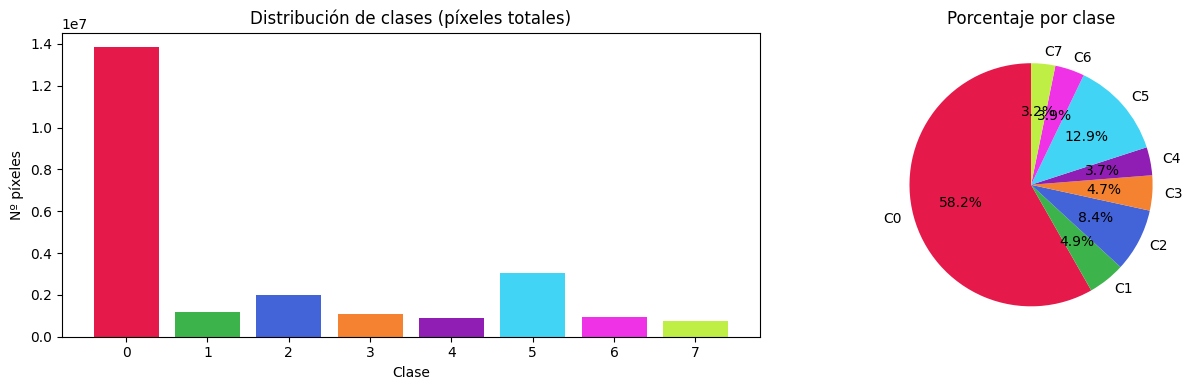

In [5]:
# --- Distribución de clases ---
class_counts = np.bincount(kag_masks.flatten().astype(np.int64))
class_pct    = class_counts / class_counts.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(range(len(class_counts)), class_counts, color=LAYER_COLORS[:len(class_counts)])
axes[0].set_title('Distribución de clases (píxeles totales)')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Nº píxeles')

axes[1].pie(class_pct, labels=[f'C{i}' for i in range(len(class_pct))],
            colors=LAYER_COLORS[:len(class_pct)], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Porcentaje por clase')

plt.tight_layout()
# plt.savefig('kaggle_class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

## Capas de cada imagen

Se verifica que todas las imágenes cuenten con la misma cantidad de capas.

In [6]:
# Capas presentes en cada imagen (excluye clase 0 = fondo)
layers_per_image_kag = []
for i in range(kag_masks.shape[0]):
    clases = np.unique(kag_masks[i])
    n_capas = len(clases[clases > 0])  # excluye fondo (clase 0)
    layers_per_image_kag.append(n_capas)

layers_per_image_kag = np.array(layers_per_image_kag)

print(f"  Capas mín / máx : {layers_per_image_kag.min()} / {layers_per_image_kag.max()}")
print(f"  Capas promedio  : {layers_per_image_kag.mean():.2f}")
print(f"  Distribución    : {np.bincount(layers_per_image_kag)}")
valores, conteos = np.unique(layers_per_image_kag, return_counts=True)
for v, c in zip(valores, conteos):
    print(f"  {c} imágenes tienen {v} capas")

  Capas mín / máx : 7 / 7
  Capas promedio  : 7.00
  Distribución    : [  0   0   0   0   0   0   0 220]
  220 imágenes tienen 7 capas


## Muestra de imágenes y máscaras

Se muestran 4 imágenes junto con sus máscaras.

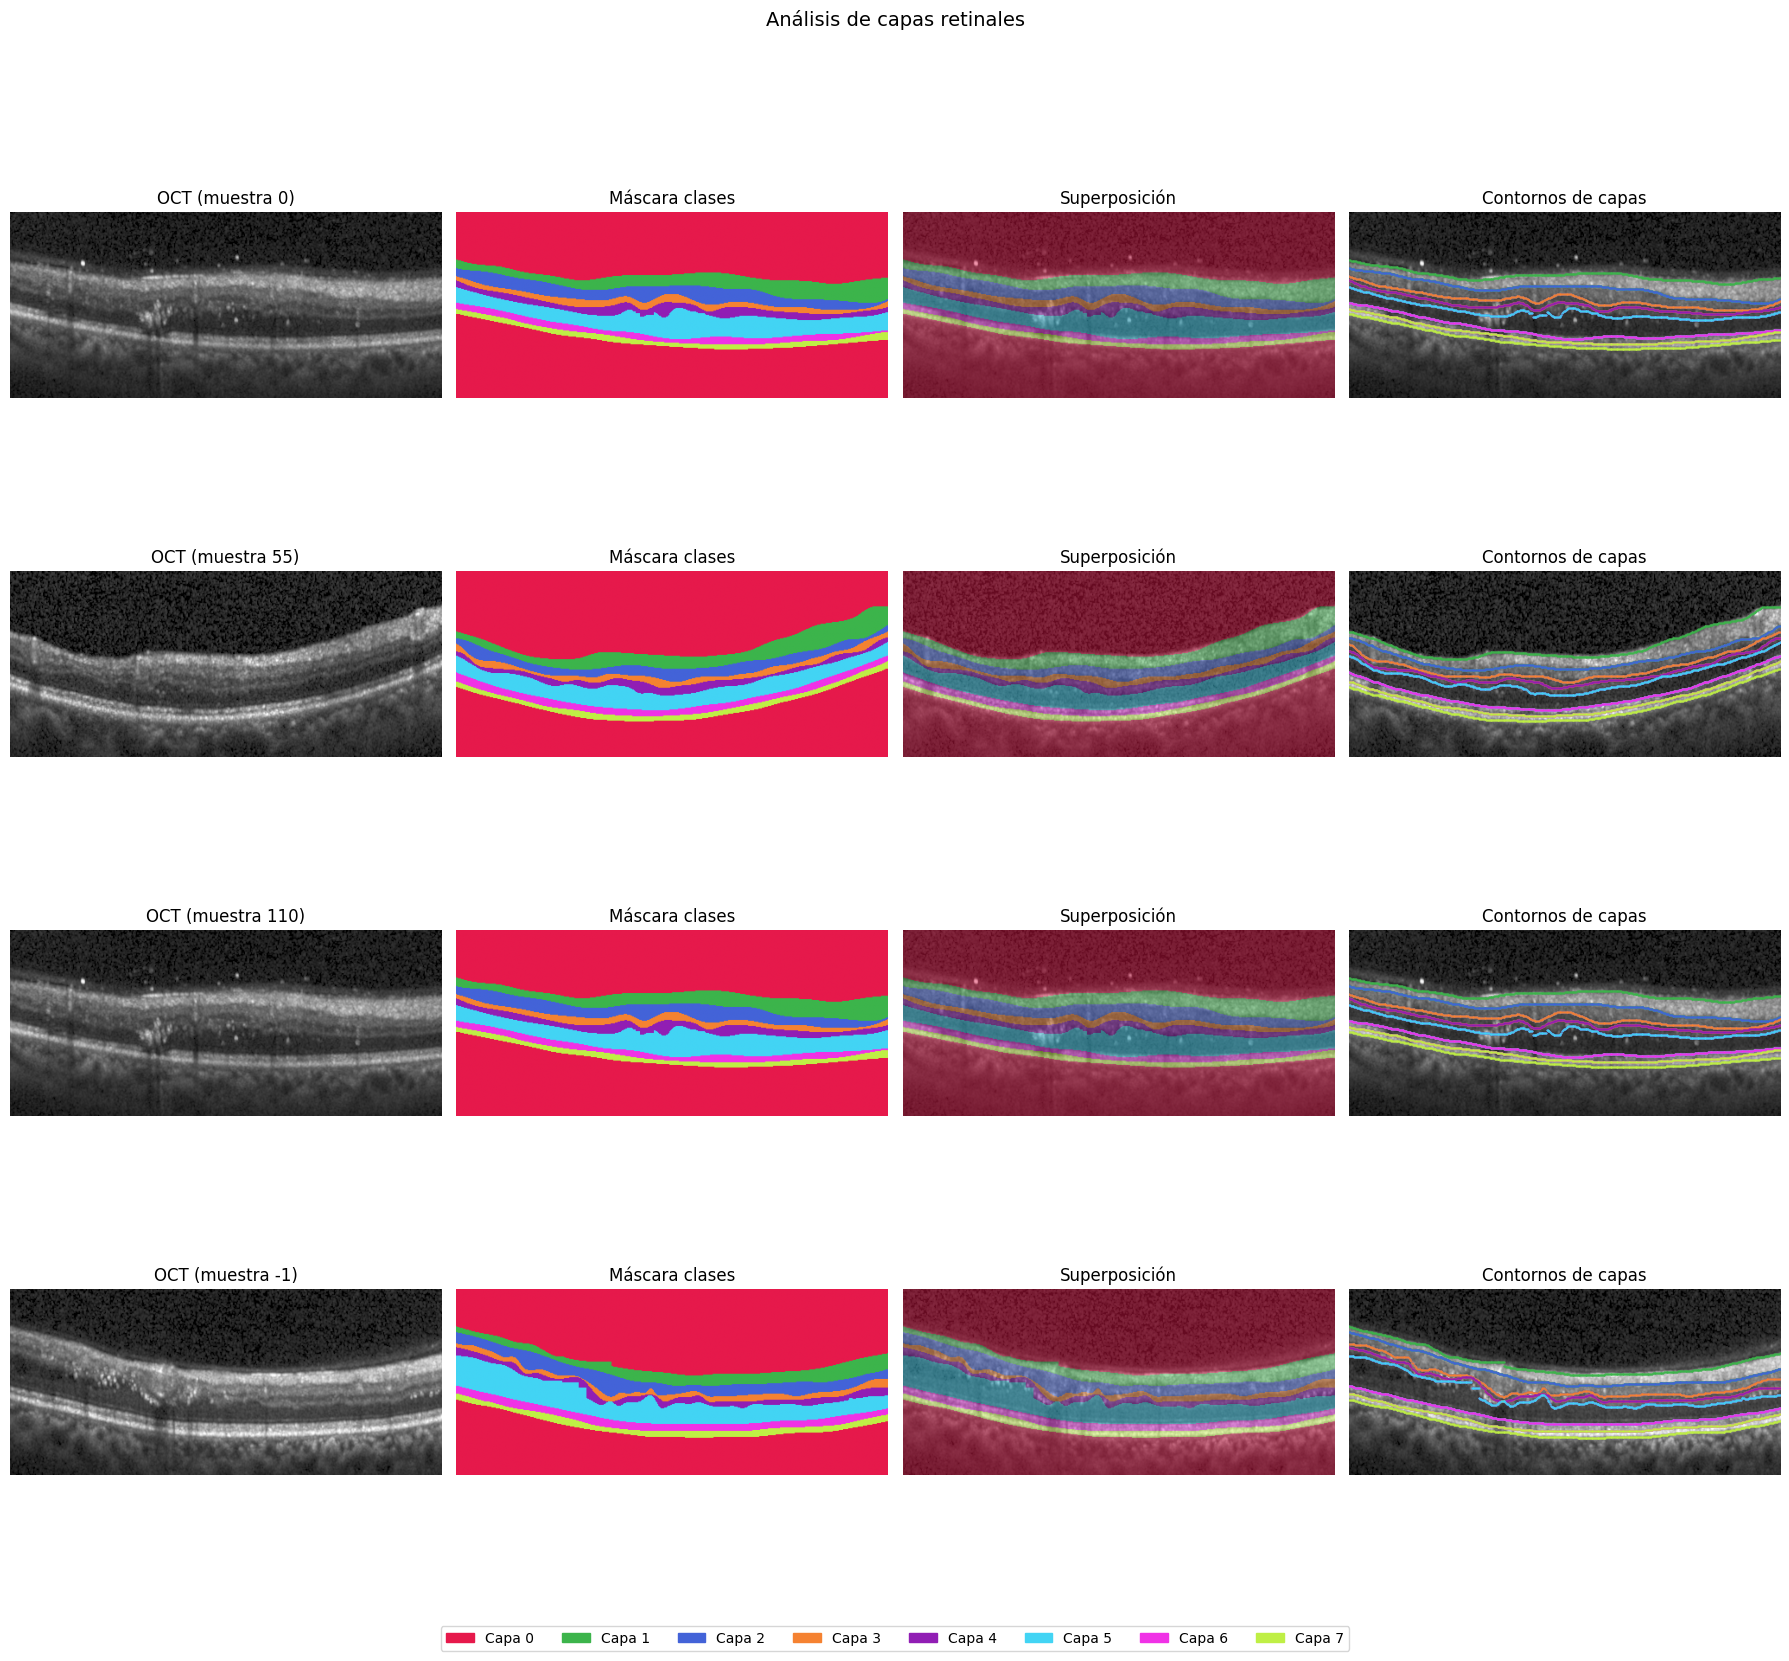

In [7]:
# --- Visualización: 4 muestras con imagen + máscara + superposición + capas ---
sample_indices = [0, kag_imgs.shape[0]//4, kag_imgs.shape[0]//2, -1]
cmap_layers = ListedColormap(LAYER_COLORS[:n_classes_kag])

fig, axes = plt.subplots(len(sample_indices), 4, figsize=(18, 4*len(sample_indices)))
fig.suptitle('Análisis de capas retinales', fontsize=14, y=1.01)

for row, idx in enumerate(sample_indices):
    img  = kag_imgs[idx]
    mask = kag_masks[idx]

    # Panel 1: imagen OCT
    axes[row, 0].imshow(img, cmap='gray')
    axes[row, 0].set_title(f'OCT (muestra {idx})')
    axes[row, 0].axis('off')

    # Panel 2: máscara de clases
    im = axes[row, 1].imshow(mask, cmap=cmap_layers, vmin=0, vmax=n_classes_kag-1)
    axes[row, 1].set_title('Máscara clases')
    axes[row, 1].axis('off')

    # Panel 3: superposición
    axes[row, 2].imshow(img, cmap='gray')
    axes[row, 2].imshow(mask, cmap=cmap_layers, alpha=0.45, vmin=0, vmax=n_classes_kag-1)
    axes[row, 2].set_title('Superposición')
    axes[row, 2].axis('off')

    # Panel 4: contornos de capas (boundaries entre clases)
    axes[row, 3].imshow(img, cmap='gray')
    for c in range(1, n_classes_kag):
        boundary = np.where(np.diff((mask == c).astype(np.int8), axis=0))
        axes[row, 3].scatter(boundary[1], boundary[0],
                             s=0.3, color=LAYER_COLORS[c % len(LAYER_COLORS)], label=f'Cap {c}')
    axes[row, 3].set_title('Contornos de capas')
    axes[row, 3].axis('off')

# Leyenda global
patches = [mpatches.Patch(color=LAYER_COLORS[i], label=f'Capa {i}') for i in range(n_classes_kag)]
fig.legend(handles=patches, loc='lower center', ncol=n_classes_kag, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
# plt.savefig('kaggle_4samples_layers.png', dpi=120, bbox_inches='tight')
plt.show()

# Entrenamiento del modelo

Como modelo de segmentación, se seleccionó la arquitectura UNet++, que es una mejora del UNet tradicional y se ha demostrado que ofrece mejores resultados en tareas de segmentación médica.

In [8]:
!pip install segmentation_models_pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.6 MB/s eta 0:00:00


In [17]:
# Imports adicionales para modelado y entrenamiento

import torch
import time
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import segmentation_models_pytorch as smp
from scipy.ndimage import distance_transform_edt


Carga de datos y preprocesamiento para UNet++

In [11]:
# Carga de datos

X = np.load(KAGGLE_IMAGES_PATH)
Y = np.load(KAGGLE_LABELS_PATH)

# (N,H,W) -> (N,1,H,W): como las imágenes son en escala de grises,
# agregamos un canal extra para que sean compatibles con modelos
# preentrenados que esperan 3 canales (RGB). El modelo se adaptará a 1 canal,
# pero el formato debe ser (N,C,H,W). Si ya tienen un canal extra, no hacemos nada.
if X.ndim == 3:
    X = X[:, None, :, :]

X = torch.tensor(X, dtype=torch.float32) / 255.0
Y = torch.tensor(Y, dtype=torch.long)

# padding: (left, right, top, bottom)
X = F.pad(X, (0, 12, 0, 8))
Y = F.pad(Y, (0, 12, 0, 8))

num_classes = int(Y.max() + 1)

# Split en entrenamiento y validación (80% train, 20% val)
n = len(X)
split = int(0.8 * n)

train_ds = TensorDataset(X[:split], Y[:split])
val_ds   = TensorDataset(X[split:], Y[split:])

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=8)

Carga del modelo preentrenado y entrenamiento con las imágenes de la retina del ojo.

In [13]:
# Modelo
# Carga del modelo preentrenado de librería segmentation_models_pytorch.
model = smp.UnetPlusPlus(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=1,
    classes=num_classes
)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

# Loss + optimizer
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Train loop
epochs = 50
patience = 6
best_val = float("inf")
bad_epochs = 0

best_path = "modelos/unetpp_smp_finetunning.pth"

for epoch in range(epochs):
    # -------- train --------
    model.train()
    train_loss = 0.0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # -------- val --------
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = loss_fn(logits, y)
            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1}/{epochs} - train loss: {train_loss:.4f} - val loss: {val_loss:.4f}")

    # -------- early stopping logic --------
    if val_loss < best_val - 1e-6:   # 1e-6 evita “mejoras” por ruido numérico
        best_val = val_loss
        bad_epochs = 0
        torch.save(model.state_dict(), best_path)
        print(f"  ✅ Mejoró val_loss. Guardado en {best_path}")
    else:
        bad_epochs += 1
        print(f"  ⏳ No mejoró. patience: {bad_epochs}/{patience}")

        if bad_epochs >= patience:
            print(f"🛑 Early stopping: {patience} épocas sin mejora.")
            break

print("Entrenamiento finalizado.")


Epoch 1/50 - train loss: 0.9495 - val loss: 0.5684
  ✅ Mejoró val_loss. Guardado en modelos/unetpp_smp_finetunning.pth
Epoch 2/50 - train loss: 0.3137 - val loss: 0.2061
  ✅ Mejoró val_loss. Guardado en modelos/unetpp_smp_finetunning.pth
Epoch 3/50 - train loss: 0.2022 - val loss: 1.0728
  ⏳ No mejoró. patience: 1/6
Epoch 4/50 - train loss: 0.1652 - val loss: 0.1278
  ✅ Mejoró val_loss. Guardado en modelos/unetpp_smp_finetunning.pth
Epoch 5/50 - train loss: 0.1343 - val loss: 0.1135
  ✅ Mejoró val_loss. Guardado en modelos/unetpp_smp_finetunning.pth
Epoch 6/50 - train loss: 0.1192 - val loss: 0.0984
  ✅ Mejoró val_loss. Guardado en modelos/unetpp_smp_finetunning.pth
Epoch 7/50 - train loss: 0.1089 - val loss: 0.0976
  ✅ Mejoró val_loss. Guardado en modelos/unetpp_smp_finetunning.pth
Epoch 8/50 - train loss: 0.1036 - val loss: 0.0956
  ✅ Mejoró val_loss. Guardado en modelos/unetpp_smp_finetunning.pth
Epoch 9/50 - train loss: 0.0985 - val loss: 0.0895
  ✅ Mejoró val_loss. Guardado en mod

# Evaluación del modelo

## Definición de métricas

Definición de métricas a utilizar:

- Dice Coefficient: Mide la similitud entre la máscara predicha y la máscara real. Se calcula como:
$$Dice = 2 \times \frac{Área~de~solapamiento}{Total~de~píxeles~en~ambas~imágenes}$$
donde TP es el número de verdaderos positivos, FP es el número de falsos positivos y FN es el número de falsos negativos.

- Intersection over Union (IoU): Mide la superposición entre la máscara predicha y la máscara real. Se calcula como:
$$IoU = \frac{Intersección}{Unión}$$

- HD (Hausdorff Distance): Mide la distancia máxima entre los bordes de la máscara predicha y la máscara real. Se calcula como:
$$HD = \max\{\sup_{x \in A} \inf_{y \in B} d(x, y), \sup_{y \in B} \inf_{x \in A} d(x, y)\}$$
donde A es el conjunto de puntos en la máscara predicha, B es el conjunto de puntos en la máscara real, y d(x, y) es la distancia entre los puntos x e y.

In [14]:
def compute_metrics_per_class(preds, targets, num_classes):
    """Calcula Dice/IoU/Hausdorff por clase."""
    results = []
    for c in range(num_classes):
        p = (preds==c)
        t = (targets==c)
        inter = (p&t).sum()
        union = (p|t).sum()
        dice  = float(2*inter/(p.sum()+t.sum()+1e-8))
        iou   = float(inter/(union+1e-8))
        # Hausdorff
        hd_vals = []
        for i in range(len(preds)):
            pi, ti = (preds[i]==c), (targets[i]==c)
            if pi.any() and ti.any():
                hd_vals.append(max(
                    distance_transform_edt(~ti)[pi].max(),
                    distance_transform_edt(~pi)[ti].max()
                ))
        hd = float(np.mean(hd_vals)) if hd_vals else 0.
        results.append({'class': c, 'dice': dice, 'iou': iou, 'hd': hd})
    return results

def measure_inference_time(model, device, n_runs=50, img_size=(256,256)):
    """Mide tiempo de inferencia promedio en ms/imagen."""
    model.eval()
    dummy = torch.randn(1, 1, *img_size).to(device)
    # Warmup
    with torch.no_grad():
        for _ in range(5):
            model(dummy)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    t0 = time.time()
    with torch.no_grad():
        for _ in range(n_runs):
            model(dummy)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    return (time.time()-t0)/n_runs*1000  # ms

In [16]:
# Pesos guardados en el paso anterior:
PTH_PATH = "modelos/unetpp_smp_finetunning.pth"

# Definición del modelo a partir de los pesos guardados
model = smp.UnetPlusPlus(
    encoder_name="resnet34",
    encoder_weights=None,  # al cargar tu .pth
    in_channels=1,
    classes=num_classes
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

state = torch.load(PTH_PATH, map_location=device)
model.load_state_dict(state)
model.eval()

# Inferencia sobre el conjunto de validación
all_preds = []
all_tgts  = []

with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device)
        logits = model(xb)                 # (B,C,H,W)
        pred = torch.argmax(logits, dim=1) # (B,H,W)

        all_preds.append(pred.cpu())
        all_tgts.append(yb.cpu())

preds = torch.cat(all_preds, dim=0).numpy()    # (N,H,W)
targets = torch.cat(all_tgts, dim=0).numpy()   # (N,H,W)


# Cálculo de métricas con las funciones definidas
metrics = compute_metrics_per_class(preds, targets, num_classes)

print("=== Métricas por clase ===")
for m in metrics:
    print(f"Class {m['class']:>2} | Dice={m['dice']:.4f} IoU={m['iou']:.4f} HD={m['hd']:.4f}")

# Promedios simples (macro)
dice_macro = np.mean([m["dice"] for m in metrics])
iou_macro  = np.mean([m["iou"] for m in metrics])
hd_macro   = np.mean([m["hd"] for m in metrics])

print("\n=== Macro promedio ===")
print(f"Dice={dice_macro:.4f} IoU={iou_macro:.4f} HD={hd_macro:.4f}")

# Tiempo de inferencia promedio
ms = measure_inference_time(model, device, n_runs=50, img_size=(224, 512))
print(f"\nTiempo inferencia: {ms:.2f} ms/imagen")


=== Métricas por clase ===
Class  0 | Dice=0.9988 IoU=0.9976 HD=1.1058
Class  1 | Dice=0.9795 IoU=0.9599 HD=1.2263
Class  2 | Dice=0.9886 IoU=0.9775 HD=1.6327
Class  3 | Dice=0.9704 IoU=0.9425 HD=1.8435
Class  4 | Dice=0.9669 IoU=0.9360 HD=2.1538
Class  5 | Dice=0.9901 IoU=0.9804 HD=1.9909
Class  6 | Dice=0.9781 IoU=0.9572 HD=1.1568
Class  7 | Dice=0.9789 IoU=0.9587 HD=1.1325

=== Macro promedio ===
Dice=0.9814 IoU=0.9637 HD=1.5303

Tiempo inferencia: 18.87 ms/imagen
